In [200]:
import pandas as pd 
import numpy as np 
import zipfile 
import os 

booking = pd.read_csv(r"C:\Clipboard Case materials\Cancellation Data Files\Booking_logs.csv")
cancel = pd.read_csv(r"C:\Clipboard Case materials\Cancellation Data Files\Cancel_logs.csv")
shifts = pd.read_csv(r"C:\Clipboard Case materials\Cancellation Data Files\Cleveland_shifts_logs.csv")

print (f"Booking Data:\n{booking.head()}")
print()
print (f"Cancel Data:\n{cancel.head()}")
print()
print (f"Shifts Data:\n{shifts.head()}")
print()

Booking Data:
                  Action ID           Created At                  Shift ID  \
0  615f58b997538d018b1163e0  2021-10-07 20:29:46  615e1de54502b9016c9a5af1   
1  61608ce36790e5016acaf149  2021-10-08 18:24:35  616060338917ec016965f9a0   
2  61677eea7dce1d016a9b7f95   2021-10-14 0:50:51  61645d1dfdd396016a697466   
3  6166159a8186c5016a54dd6d  2021-10-12 23:09:15  616093710daae0016926f60d   
4  616391cec03fa3016a12a316   2021-10-11 1:22:23  614b6df64cd99701667bb099   

        Action                 Worker ID               Facility ID   Lead Time  
0  SHIFT_CLAIM  5c993c695d096c00167e6845  615b46a1c7135401876cdd06  144.504167  
1  SHIFT_CLAIM  61587d5a2ced390187554556  5fbd2a01582f640016a4cb09  200.590278  
2  SHIFT_CLAIM  60898a05cd5d9c016675a996  5c3cc2e3a2ae5c0016bef82c   73.652778  
3  SHIFT_CLAIM  60ba35153c4b4f016610c5cd  60c1495470d2440166e23cb0  118.846111  
4  SHIFT_CLAIM  60de429441198701669b529a  614900f003c26b0166e08737  178.627222  

Cancel Data:
                 

In [ ]:
#Table shapes 
print (f"Booking Data Shape: {booking.shape}")
print (f"Cancel Data Shape: {cancel.shape}")
print (f"Shifts Data Shape: {shifts.shape}") 



Booking Data Shape: (127005, 9)
Cancel Data Shape: (78073, 12)
Shifts Data Shape: (41040, 13)
Total number of unique workers in cleveland data: 997


In [ ]:
# Workers who appear in ANY of the three tables
booking_workers = set(booking["Worker ID"].dropna())
cancel_workers = set(cancel["Worker ID"].dropna())
shifts_workers = set(shifts["Worker ID"].dropna())

all_workers = booking_workers | cancel_workers | shifts_workers #further thoughts

print(f"Workers in booking logs:   {len(booking_workers):,}")
print(f"Workers in cancel logs:    {len(cancel_workers):,}")
print(f"Workers in Cleveland shifts: {len(shifts_workers):,}")
print(f"\nTotal unique workers (any table): {len(all_workers):,}")

# Workers who NCNS'd
ncns_workers = set(cancel[cancel["Action"] == "NO_CALL_NO_SHOW"]["Worker ID"].dropna())
print(f"\nWorkers who NCNS'd at least once: {len(ncns_workers):,} ({len(ncns_workers)/len(all_workers)*100:.1f}%)")

# The 1,505 with 3+ NCNS
ncns_per_worker = cancel[cancel["Action"] == "NO_CALL_NO_SHOW"].groupby("Worker ID").size()
workers_3plus = ncns_per_worker[ncns_per_worker >= 3]
print(f"Workers with 3+ NCNS: {len(workers_3plus):,} ({len(workers_3plus)/len(all_workers)*100:.1f}%)")



Workers in booking logs:   6,841
Workers in cancel logs:    9,933
Workers in Cleveland shifts: 997

Total unique workers (any table): 11,062

Workers who NCNS'd at least once: 4,774 (43.2%)
Workers with 3+ NCNS: 1,505 (13.6%)


In [202]:
TAKE_RATE = 0.22  # given in case assumptions

#### WHAT EACH TABLE CONTAINS
#### GOAL: Understand what this table contains before doing any analysis. You wouldn't cook with ingredients you haven't looked at first.

In [203]:
# Booking Data 
print(booking.columns) #show columns and datatypes 
print(booking.head()) # shows first 5 rows of data 

# check for mising values 
print(booking.isnull().sum())

# What time period does this cover?
print()
print(f"Booking Data Time Period: {booking['Created At'].min()} to {booking['Created At'].max()}")

# What does the "Action" column tell us? in booking
print("\n --- Booking 'Action' Column Analysis:---")
print(booking['Action'].value_counts())
# returns shift_claim, indicating the shift has been claimeed by a worker.

# Lead Time: Time between Action and Shift Start Time in hours 
print("\n --- Booking 'Lead Time' Analysis:---")
print(booking['Lead Time'].describe())
# data type is float, so we can calculate average, median, min and max lead time.
# we have some negative lead times, which means that some shifts were claimed after the shift start time. This could be due to last minute bookings or data entry errors. We should investigate this further to understand the reasons behind it.
print(f"Maximum Lead Time (hours): {booking['Lead Time'].max():.2f}")  

print()
#unique counts for worker id, shift id and facility id in booking data. This will help us understand the scale of the data and how many unique entities we are dealing with in terms of workers, shifts, and facilities.
book_unique_worker_ids = booking['Worker ID'].nunique()
print(f"Number of unique Worker IDs: {book_unique_worker_ids}")    
book_unique_shift_ids = booking['Shift ID'].nunique()
print(f"Number of unique Shift IDs: {book_unique_shift_ids}")    
book_unique_facility_ids = booking['Facility ID'].nunique()
print(f"Number of unique Facility IDs: {book_unique_facility_ids}")


Index(['Action ID', 'Created At', 'Shift ID', 'Action', 'Worker ID',
       'Facility ID', 'Lead Time'],
      dtype='object')
                  Action ID           Created At                  Shift ID  \
0  615f58b997538d018b1163e0  2021-10-07 20:29:46  615e1de54502b9016c9a5af1   
1  61608ce36790e5016acaf149  2021-10-08 18:24:35  616060338917ec016965f9a0   
2  61677eea7dce1d016a9b7f95   2021-10-14 0:50:51  61645d1dfdd396016a697466   
3  6166159a8186c5016a54dd6d  2021-10-12 23:09:15  616093710daae0016926f60d   
4  616391cec03fa3016a12a316   2021-10-11 1:22:23  614b6df64cd99701667bb099   

        Action                 Worker ID               Facility ID   Lead Time  
0  SHIFT_CLAIM  5c993c695d096c00167e6845  615b46a1c7135401876cdd06  144.504167  
1  SHIFT_CLAIM  61587d5a2ced390187554556  5fbd2a01582f640016a4cb09  200.590278  
2  SHIFT_CLAIM  60898a05cd5d9c016675a996  5c3cc2e3a2ae5c0016bef82c   73.652778  
3  SHIFT_CLAIM  60ba35153c4b4f016610c5cd  60c1495470d2440166e23cb0  118.846111  

In [204]:
# Think of these as:
#   Action ID   = unique ID for this specific event
#   Created At  = when the booking happened (date + time)
#   Shift ID    = which shift was booked
#   Action      = what type of event (spoiler: it's always SHIFT_CLAIM)
#   Worker ID   = which worker booked it
#   Facility ID = which facility the shift is at
#   Lead Time   = hours between booking and shift start
 
# .head() shows the first 5 rows. This lets you SEE actual
# data values, not just column names. Look at each column
# and make sure the values make sense.
#
# For example, Lead Time should mostly be positive numbers
# (you book a shift BEFORE it starts). If you see negative
# numbers, that means someone booked AFTER the shift started.

# --- 2c: What data types are the columns? ---
# This tells you how Python is treating each column:
#   "str"           = text (IDs, names)
#   "datetime64"    = dates and times
#   "float64"       = decimal numbers (like Lead Time)
#
# Why this matters: if a column that SHOULD be a number
# shows up as "str" (text), something went wrong in loading.
# In this case, everything looks correct.

# --- 2d: Are there any missing values? --
# .isnull() checks every cell: is it empty?
# .sum() counts how many empty cells per column
#
# You'll see Worker ID has 140 missing values.
# That's 140 out of 127,005 rows = 0.1%. Negligible.
# It probably means 140 bookings where the worker ID wasn't recorded properly. Not worth investigating.

# --- 2e: What time period does this cover? ---
# .min() and .max() on a date column give you the range.
# You'll see Aug 2021 to Apr 2022 — about 8 months of data

# --- 2f: The "Action" column ---
# .value_counts() counts how many rows have each unique value.
# Result: SHIFT_CLAIM = 127,005
# That means EVERY row in this table is a shift being claimed
# by a worker. There's only one type of event here.
# Simple — this table is just "who booked what, and when."

# --- 2g: The "Lead Time" column ---
# .describe() gives you a statistical summary:
#   count = how many values (should match row count minus nulls)
#   mean  = average (200 hours ≈ 8 days in advance)
#   std   = standard deviation (how spread out the values are)
#   min   = smallest value (-3271 hours = someone "booked" 136
#           days AFTER the shift — probably a data quirk)
#   25%   = 25th percentile (25% of bookings happen ≤62 hours out)
#   50%   = median (half book ≤147 hours out ≈ 6 days)
#   75%   = 75th percentile (75% book ≤283 hours out ≈ 12 days)
#   max   = largest value (2134 hours ≈ 89 days in advance)
#
# KEY TAKEAWAY: Most workers book 2-12 days in advance.
# The average is ~8 days. Some book very last-minute (<24h) and some book very far out (>2 weeks).

# --- 2h: How many unique workers, shifts, facilities? ---
# .nunique() = "number of unique values"
#
# Workers: 6,841 — this is how many individual workers
#   booked at least one shift across the whole marketplace.
# Shifts: 108,662 — total unique shifts that got booked.
# Facilities: 1,118 — total facilities using the platform.
#
# IMPORTANT: This is ALL markets, not just Cleveland.
# The booking and cancel logs cover the whole marketplace.
# Only the shifts table is Cleveland-specific.

### 3: LOOKING AT THE CANCEL TABLE

In [205]:
# Cancel logs summary

# --- 3a: Columns ---
# PLUS "Start" (when the shift was supposed to start). This extra column exists because for cancellations, the timing relative to shift start 
# is critical information.

# --- 3b: First few rows ---
print(cancel.head()) # shows first 5 rows of data
print() 
print(cancel.columns) #show columns and datatypes
print() 
# --- 3c: Missing values ---
print(cancel.isnull().sum())

# --- 3d: Date range ---
print()
print(f"Cancel Logs Time Period: {cancel['Created At'].min()} to {cancel['Created At'].max()}")
print() 

# --- 3e: The "Action" column — THE MOST IMPORTANT COLUMN ---
print(cancel["Action"].value_counts())
print() 
# from having two categories showing in action column 
# an ncns count is needed to show seperation from standard cancellations count 

ncns_count = (cancel["Action"] == "NO_CALL_NO_SHOW").sum()
total_cancels = len(cancel)
print(f"\nNCNS is {ncns_count} out of {total_cancels} cancels")
print(f"That's {ncns_count / total_cancels * 100:.1f}%")
print() 

# --- 3f: The "Lead Time" column ---
# Same concept as booking Lead Time, but now it means:

# "How many hours before the shift did they cancel?"
#print("cancel Lead Time stats:")
print(cancel["Lead Time"].describe())


# --- 3g: Let's split cancellations into categories ---

cancel["is_late"] = cancel["Lead Time"] < 24
cancel["is_ncns"] = cancel["Action"] == "NO_CALL_NO_SHOW"

# How many of each?
late_count = cancel["is_late"].sum()
ncns_count = cancel["is_ncns"].sum()
early_count = total_cancels - late_count
 
print(f"\nEarly cancels (≥24h notice):  {early_count:,} ({early_count/total_cancels*100:.1f}%)")
print(f"Late cancels (<24h notice):   {late_count:,} ({late_count/total_cancels*100:.1f}%)")
print(f"   of which NCNS:             {ncns_count:,} ({ncns_count/total_cancels*100:.1f}%)")

                  Action ID           Created At                  Shift ID  \
0  61a07227f36d1e0186381d10   2021-11-26 5:35:36  619d2f2a5db209018533a507   
1  617bb2e2ae50230185b05985   2021-10-29 8:37:55  614fa1ed22aa37018320e6ed   
2  61c90bb026c4c8018adc0820   2021-12-27 0:41:20  61ba75ff55eb55018586568b   
3  6186ce5dba1046018596162c  2021-11-06 18:50:06  6169aebc4dcbb2016aad106c   
4  618987925daf8001857ffd84  2021-11-08 20:24:50  6179b80d9c79750169c98f54   

            Action                 Worker ID                Start  \
0  NO_CALL_NO_SHOW  5e1fa8d8170f34001633e511   2021-11-25 6:00:00   
1    WORKER_CANCEL  5cf573381648900016c41377  2021-10-29 13:00:00   
2    WORKER_CANCEL  61c24b6132278b018511e941  2021-12-27 23:45:00   
3    WORKER_CANCEL  60f9a88678a10501661b36d0  2021-11-13 12:00:00   
4    WORKER_CANCEL  615d413f21f03c016c7523ff  2021-11-23 20:00:00   

                Facility ID   Lead Time  
0  6182c3fb79773801854c081d  -23.593056  
1  5ff4f626909f7a00160d06fd    4

In [ ]:
# Worker ID has 191 nulls — again negligible (0.2%)

# time period 
# Sep 2021 to Jul 2022.
# NOTE: Most of the data is concentrated in Oct 2021 – Jan 2022.
# The later months (Feb–Jul 2022) have very few events and
# are almost all NCNS. This is probably retroactive logging,
# not real-time activity. Stick to Oct–Jan for clean analysis.

# The action column values in Cancel logs 
# Result:
#   WORKER_CANCEL      66,108  (84.7%)
#   NO_CALL_NO_SHOW    11,965  (15.3%)
#
# Two types of events:
#
# WORKER_CANCEL = the worker actively canceled their shift.
#   They told the platform "I'm not coming."
#   This gives the marketplace SOME chance to find a replacement.
#
# NO_CALL_NO_SHOW (NCNS) = the worker just didn't show up.
#   No warning. No communication.
#   The facility is left with an empty shift and no time to react.
#
# The case study tells us NCNS is the MOST damaging type.
# Even though it's only 15% of cancels, it has outsized impact.
 
# --- 3f: The "Lead Time" column ---
# CRITICAL INSIGHT: look at the minimum. It's -4,210 hours.
# Negative lead time means they "canceled" AFTER the shift started. That's what NCNS looks like in the data — the system logs the NCNS event after the shift 
# has passed.
# The median is 36 hours — meaning half of all cancellations happen less than 1.5 days before the shift. That's tight.
#
# The 25th percentile is 2.25 hours — a quarter of all cancels happen less than 2.5 HOURS before the shift starts.
# That's basically no warning at all - extremely late cancellations 

# --- 3g: Let's split cancellations into categories ---

# WHAT THIS MEANS:
# 53.5% of cancels happen with ≥24h notice (not great but manageable)
# 46.5% happen with <24h notice (bad — facility can barely react)
# 15.3% are NCNS (worst — facility gets zero warning)
#
# Combined, late cancels + NCNS = 61.8% of all cancellation events.
# more than half of all cancellations leave the facility scrambling.

#late cancels that go unfilled 
unfilled_late_cancels = cancel[(cancel["is_late"] == True) & (cancel["is_ncns"] == False)]
print(unfilled_late_cancels)
# unfilled would mean it is not verified in the shifts table, we can check using a copy of shifts table and merging 
unfilled_late_cancels_shifts = unfilled_late_cancels.merge(shifts, on=["Shift ID", "Facility ID"], how="left", suffixes=("_cancel", "_shift"))
print(unfilled_late_cancels_shifts[["Shift ID", "Facility ID", "is_late", "is_ncns", "Verified"]])
#count of unfilled late cancels
unfilled_late_cancel_count = unfilled_late_cancels_shifts["Verified"].isnull().sum()
print(f"\nUnfilled late cancels: {unfilled_late_cancel_count:,} ({unfilled_late_cancel_count/total_cancels*100:.1f}%)")



                      Action ID           Created At  \
1      617bb2e2ae50230185b05985   2021-10-29 8:37:55   
2      61c90bb026c4c8018adc0820   2021-12-27 0:41:20   
7      61c79b256d87a401878e80dd  2021-12-25 22:28:53   
8      61c383873672e901856bebc0  2021-12-22 19:59:04   
9      61f6ec03d420f3018a926b3e  2022-01-30 19:50:27   
...                         ...                  ...   
78054  61c214da063bdd01853e0b72  2021-12-21 17:54:34   
78057  61f60edaa8a902018ac96593   2022-01-30 4:06:51   
78064  61c2176d32278b0185081381  2021-12-21 18:05:33   
78066  61b8d11a6f21f801851c7c67  2021-12-14 17:15:06   
78070  61acb4b765e7600180293a43  2021-12-05 12:46:47   

                       Shift ID         Action                 Worker ID  \
1      614fa1ed22aa37018320e6ed  WORKER_CANCEL  5cf573381648900016c41377   
2      61ba75ff55eb55018586568b  WORKER_CANCEL  61c24b6132278b018511e941   
7      61b10ab123254d0187c47493  WORKER_CANCEL  616d2a28689088016b4413b4   
8      61bc51368bd72601

### 4. Cleveland Shifts Table 

In [229]:
# Cleveland Shift Table 
# --- 4a: Columns ---
print(shifts.columns) 
print()

# --- 4b: First few rows ---
print(shifts.head()) 
print()

print("missing values in shifts data:")
# --- 4c: Missing values 
print(shifts.isnull().sum())
print()

# What time period does this cover?
print("time period covered in shifts data:")
print(f"Cleveland Shift Data Time Period: {shifts['Created At'].min()} to {shifts['Created At'].max()}")
print() 

# --- 4d: The "Agent Req" column (worker type needed) ---
print("Agent Req value counts:")
print(shifts["Agent Req"].value_counts())
print( "agent required percentages:")
agent_req_counts = shifts["Agent Req"].value_counts()
agent_req_percentages = agent_req_counts / len(shifts) * 100 
print(agent_req_percentages.round(2))
print()

# --- 4e: The "Shift Type" column ---
print("Shift Type value counts:")
print(shifts["Shift Type"].value_counts())
print() 

# --- 4f: The "Verified" column (did someone actually work it?) ---
print("Verified value counts:")
print(shifts['Verified'].value_counts())
print()

# --- 4g: The "Deleted" column ---
print("Deleted value counts:")
deleted_count = shifts["Deleted"].notna().sum()
not_deleted = shifts["Deleted"].isna().sum()
print()

print(f"Deleted by facility:     {deleted_count:,} ({deleted_count/len(shifts)*100:.1f}%)")
print(f"Not deleted:             {not_deleted:,} ({not_deleted/len(shifts)*100:.1f}%)")

# --- 4h: The "Charge" column ---
print("Charge column stats:")
print(shifts["Charge"].describe())
print() 

# --- 4i: The "Time" column (shift duration) ---
print("Time column stats:")
print(shifts["Time"].describe())

print() 

#additional understanding for proposal 
#total cleveland shifts
total_cleveland_shifts = len(shifts)

#how many cleveland shifts get filled (verified = True)
filled_cleveland_shifts = shifts[shifts["Verified"] == True].shape[0]

#% of cleveland shifts that get filled
filled_percentage = filled_cleveland_shifts / total_cleveland_shifts * 100
print(f"Total Cleveland Shifts: {total_cleveland_shifts:,}")
print(f"Filled Cleveland Shifts: {filled_cleveland_shifts:,}")
print(f"Percentage of Cleveland Shifts Filled: {filled_percentage:.1f}%")
#% of shifts unfilled (verified = False)
unfilled_cleveland_shifts = shifts[shifts["Verified"] == False].shape[0]
unfilled_percentage = unfilled_cleveland_shifts / total_cleveland_shifts * 100
print(f"Unfilled Cleveland Shifts: {unfilled_cleveland_shifts:,}")
print(f"Percentage of Cleveland Shifts Unfilled: {unfilled_percentage:.1f}%")


Index(['Shift ID', 'Worker ID', 'Facility ID', 'Start', 'Agent Req', 'End',
       'Deleted', 'Shift Type', 'Created At', 'Verified', 'Charge', 'Time',
       'status'],
      dtype='object')

                   Shift ID                 Worker ID  \
0  61732a2ad690c401690cf273  614627661afb050166fecd99   
1  61732a4fd690c401690cf307  60d5f4c8a9b88a0166aedaca   
2  61732ab7d6e633016acd05e2  5d7fb6319b671100167be1f1   
3  61732c33d6e633016acd11fc  613503b78b28c60166060efe   
4  61759081801438016ae23301  6099c93f2a957601669549c3   

                Facility ID                Start Agent Req  \
0  5f9c169622c5c50016d5ba32  2021-10-27 23:00:00       LVN   
1  5f9c169622c5c50016d5ba32  2021-10-28 11:00:00       CNA   
2  5f9c169622c5c50016d5ba32  2021-10-30 19:00:00       LVN   
3  5e6bd68c8d921f0016325d09  2021-10-25 18:30:00       CNA   
4  61704cc1f19e4d0169ec4ac5   2021-11-03 2:00:00       CNA   

                   End Deleted Shift Type           Created At  Verified  \
0   2021-10-28 

In [ ]:
# The case study tells me to treat Cleveland as representative of the whole marketplace — so everything we find here applies everywhere.
# Twelve columns: 
#   Shift ID    = unique ID for this shift
#   Worker ID   = who was assigned to work it (NaN if nobody)
#   Facility ID = which facility posted it
#   Start       = when the shift starts
#   Agent Req   = what type of worker is needed (CNA, LVN, RN, etc.)
#   End         = when the shift ends
#   Deleted     = NaN if active, a number if facility deleted it
#   Shift Type  = am/pm/noc/custom
#   Created At  = when the shift was posted
#   Verified    = True if someone actually worked it, False otherwise
#   Charge      = how much the facility pays for this shift ($)
#   Time        = shift duration in hours

#missing values 
# Key findings:
#   Worker ID: 20,035 nulls out of 41,040 rows
#     This means ~49% of shifts have NO worker assigned.
#     These are shifts that never got filled — nobody claimed them.
#     This is a HUGE number and tells you the marketplace has a fundamental supply problem.
#
#   Deleted: 27,058 nulls
#     Remember, NaN means NOT deleted. So 27,058 shifts were not deleted by the facility. 41,040 - 27,058 = 13,982
#     WERE deleted. 
#
#   Start: 1 null — one shift with no start time. Ignore 
 
# --- 4d: The "Agent Req" column (worker type needed) ---
 # Result:
#   CNA          24,662  (60.1%)  ← Certified Nursing Assistant
#   LVN          11,277  (27.5%)  ← Licensed Vocational Nurse
#   RN            3,139  (7.6%)   ← Registered Nurse
#   NURSE         1,907  (4.6%)   ← Generic nurse category
#   CAREGIVER        31           ← tiny, ignore
#   Medical Tech     12           ← tiny, ignore
#   PT                9           ← tiny, ignore
#   Medical Aide      3           ← tiny, ignore
#
# CNA dominates — 60% of all shifts are for CNAs.
# This makes sense: CNAs are the most entry-level role,
# facilities need the most of them, and they're cheapest.
# LVNs are the second-biggest group, RNs are specialist.
#
# The NURSE category is odd — we'll see later it has $0 charge
# and almost no verified shifts. Treat it as a data anomaly.

# --- 4e: The "Shift Type" column ---
# Result:
#   pm       14,232 (34.7%)  ← afternoon/evening shifts
#   am       13,951 (34.0%)  ← morning shifts
#   noc      11,446 (27.9%)  ← nocturnal/overnight shifts
#   custom    1,411 (3.4%)   ← non-standard times
#
# Fairly even split between AM, PM, and NOC.
# "custom" is small — probably special arrangements.

# --- 4f: The "Verified" column (did someone actually work it?) ---

# Result:
#   False    24,640 (60.0%)
#   True     16,400 (40.0%)
#
# ONLY 40% of shifts get worked.
# 60% of shifts FAIL — either nobody shows up, or the facility deletes the shift.
#
# This is the single most important baseline number.
# remember one stat from the whole dataset, it's this: the marketplace fails more often than it succeeds.

#4g: The "Deleted" column
# 13,982 shifts (34.1%) were deleted by the facility.
# This could mean the facility no longer needed the shift
# (e.g., they found someone through another channel, or
# the patient was discharged) or they had trouble filling it and gave up.

# 4h: The "Charge" column
# Result:
# Average: $36.35 per shift
# Median:  $37.00
# Min:     $0.00  ← those NURSE shifts with $0
# Max:     $120.00
#
# The 22% take rate means Clipboard keeps:
# $36.35 × 0.22 = $8.00 per completed shift on average.

# also checked charge by worker type that confirms that higher skill is higher pay 
#   RN    ~$63  (most expensive — specialized skill)
#   LVN   ~$47  (mid-range)
#   CNA   ~$31  (cheapest — most basic role)
#   NURSE ~$0   (data anomaly)

# lower pay for CNA shifts could be a factor in why they're more likely to be canceled or not filled. Facilities might prioritize filling higher-paying shifts (like RN) because they are more critical and harder to fill, while being more willing to let lower-paying shifts (like CNA) go unfilled or cancel them if they can't find a worker. This could contribute to the high failure rate in the marketplace, especially for the most common shift type (CNA).

# 4i: The "Time" column (shift duration)
# Result:
# Average: 7.6 hours (typical work shift)
# Median:  7.5 hours
# Most shifts are 7-8 hours. Some are shorter (4h),
# some longer (12h+, probably overnight doubles).
# Not much to act on here — shift length isn't the problem.

#additional action: can cross-reference shift duration with cancellation data to see if longer or shorter shifts have higher cancellation rates

#cleveland shift data pie chart for shift outcomes (verified, deleted, unfilled)



### What is in each table that jumps out. 
#### Booking Logs 
- Missing values in 140  Worker ID. 
- We can see that the data covers a period from 2021-08-13 to 2022-04-12, which is a 1-year period
#### Cancelled Logs 
- 191 missing values in Worker ID 
- We can see that the data covers a period from 2021-09-06 11:06:36 to 2022-07-09 5:05:31

#### Cleveland Shift Data 
- Worker ID (20035) and Deleted (27058) columns have missing values 
- Shift Data Time Period: 2021-08-16 18:09:54 to 2022-04-04 19:50:32

In [209]:
## let's figure out what each column is telling us. 
# The best way is to look a the unique values for categorical columns, and the distribution (min/max/average) for numerical ones.

In [ ]:


# Cancel Logs Analysis
print("\n --- Cancel Logs 'Reason' Column Analysis:---")
print(cancel['Action'].value_counts())  

#   WORKER_CANCEL    = worker canceled before the shift
#   NO_CALL_NO_SHOW  = worker just didn't show up

print("\n--- Cancel: 'Lead Time' ---")
print(cancel["Lead Time"].describe())
# Lead Time: Time between Action and Shift Start Time in hours


# Cleveland Shifts Analysis
print("\n--- Cleveland Shifts: 'Shift Type' ---")
print(shifts['Shift Type'].value_counts())     

# "Agent Req" — what type of healthcare worker was needed?
print("\n--- Shifts: 'Agent Req' (worker type needed) ---")
print(shifts["Agent Req"].value_counts())


# NaN means not deleted. A number means it WAS deleted.
print("\n--- Shifts: 'Deleted' (was the shift deleted by the facility?) ---")
print(shifts["Deleted"].value_counts(dropna=False))
# This is a critical column to analyze, as it indicates whether the facility canceled the shift. We can analyze the distribution of deleted shifts and see if there are any patterns, such as certain facilities having higher deletion rates or certain shift types being more likely to be deleted. Additionally, we can cross-reference this with the booking and cancel logs to see if deleted shifts correlate with higher cancellation rates or no-shows.

# "Charge" — how much the facility pays (per hour? per shift?)
print("\n--- Shifts: 'Charge' ---")
print(shifts["Charge"].describe())

# "Time" — shift duration in hours
# let's analyze the distribution of shift durations to see if there are any patterns in how long shifts typically last and if certain shift durations are more prone to cancellations. We can do this by looking at the descriptive statistics for the "Time" column, such as the average, median, minimum, and maximum shift durations. Additionally, we can cross-reference shift duration with cancellation data to see if longer or shorter shifts have higher cancellation rates.
print("\n--- Shifts: 'Time' (shift duration in hours) ---")
print(shifts["Time"].describe())

# let's also analyze if there is any correlation between shift duration and cancellation rates, as this could indicate if longer or shorter shifts are more prone to cancellations. We can do this by merging the shifts data with the cancel logs on Shift ID and Facility ID, and then calculating the cancellation rate for different shift durations to see if there are any patterns in how shift length affects cancellation likelihood.
# shift start time may help understand if certain times of day are more prone to cancellations. We can analyze the distribution of shift start times and see if there are any patterns, such as shifts starting in the early morning or late at night having higher cancellation rates. We can do this by extracting the hour from the shift start time and analyzing the cancellation rates for different time blocks throughout the day. This could provide insights into when workers and what worker types are more likely to cancel their shifts and help us identify potential issues with scheduling or worker preferences.
# "Verified" — did someone actually show up and work?

print("\n--- Shifts: 'Verified' (did someone work it?) ---")
print(shifts["Verified"].value_counts())
# This is a critical column to analyze, as it indicates whether the shift was actually worked or not. We can analyze the distribution of verified shifts and see if there are any patterns, such as certain facilities having lower verification rates or certain shift types being less likely to be verified. Additionally, we can cross-reference this with the booking and cancel logs to see if unverified shifts correlate with higher cancellation rates or no-shows. This could help us understand the reliability of the workforce and identify potential issues with worker attendance or scheduling practices.
# let's also check if there are any shifts that were marked as verified but have corresponding cancellation records, as this could indicate discrepancies in the data or potential issues with the verification process. We can do this by merging the shifts data with the cancel logs on Shift ID and Facility ID, and then filtering for records where the shift is marked as verified but has a corresponding cancellation record. Analyzing these cases could provide insights into potential data quality issues or areas where the verification process may need improvement.



 --- Cancel Logs 'Reason' Column Analysis:---
Action
WORKER_CANCEL      66108
NO_CALL_NO_SHOW    11965
Name: count, dtype: int64

--- Cancel: 'Lead Time' ---
count    78073.000000
mean       105.907654
std        215.991052
min      -4210.099722
25%          2.254167
50%         36.302778
75%        200.658056
max       1854.236667
Name: Lead Time, dtype: float64

--- Cleveland Shifts: 'Shift Type' ---
Shift Type
pm        14232
am        13951
noc       11446
custom     1411
Name: count, dtype: int64

--- Shifts: 'Agent Req' (worker type needed) ---
Agent Req
CNA                   24662
LVN                   11277
RN                     3139
NURSE                  1907
CAREGIVER                31
Medical Technician       12
PT                        9
Medical Aide              3
Name: count, dtype: int64

--- Shifts: 'Deleted' (was the shift deleted by the facility?) ---
Deleted
NaN     27058
True    13982
Name: count, dtype: int64

--- Shifts: 'Charge' ---
count    41040.000000
mean

In [ ]:
#do longer or shorter shifts have higher cancellation rates?
# To analyze whether longer or shorter shifts have higher cancellation rates, we can merge the shifts data with the cancel logs on Shift ID and Facility ID to create a combined dataset. Then, we can categorize shifts into different duration buckets (e.g., 0-4 hours, 4-8 hours, 8-12 hours, etc.) and calculate the cancellation rate for each bucket. This will allow us to see if there is a correlation between shift duration and cancellation likelihood. We can also visualize this data using a bar chart or line graph to clearly show any trends in cancellation rates based on shift length.


#### after reviewing the tables, what their columns mean to the case. I came up with some questions that should help drive analysis into each table 

#### For booking logs
- we have some negative lead times, which means that some shifts were claimed after the shift start time. This could be due to last minute bookings or data entry errors. We should investigate this further to understand the reasons behind it.

#### Cleveland shift logs 
#### shift-type
 - am, pm, noc (overnight) shifts. This could be useful to understand if certain shift types are more prone to cancellations.
#### Agent Req
- this could be useful to understand if certain types of healthcare workers are more prone to cancellations. For example, if we see that shifts requiring a certain type of worker have a higher cancellation rate, it could indicate a shortage of that type of worker or other issues related to that role.
- is there a type of HCP that is more likely to get deleted? that is NCNS prone? 
#### Deleted
- Deleted — was the shift removed/canceled by the facility?

#### Charge 
- let's also check if there are any shifts with a charge of $0, as this could indicate data entry errors. We can do this by filtering the shifts data for records where the charge is equal to 0 and analyzing those records to understand the context behind them. If there are a significant number of $0 charges, it could indicate a potential issue with the billing system or special arrangements between facilities and workers that we need to understand better.
- Assumeption: NURSE shifts (n=1,907) show $0 charge and near-zero verification; excluded from revenue calculations

### 5. Joining the tables 

In [211]:
#5. Cross-Referencing the Three Tables

# The three tables are linked by "Shift ID". A single shift
# can appear in:
#   - shifts table (it was posted)
#   - booking table (someone claimed it)
#   - cancel table (someone canceled or NCNS'd it)

#not every shift appears in all three tables. For example:

#   - A shift that was posted but never claimed → only in shifts
#   - A shift that was claimed and worked → in shifts + booking
#   - A shift that was claimed then canceled → in shifts + booking + cancel

#similar columns between all tables
# Shift ID    = unique ID for this shift

# check if all the booking and cancel logs are for cleveland shifts by comparing the unique shift IDs in the booking and cancel tables with those in the shifts table. This will help us confirm that the booking and cancel logs are indeed representative of the Cleveland market, as stated in the case study. We can do this by extracting the unique Shift IDs from each table and then checking for overlaps to see if all booking and cancel events correspond to shifts that were posted in Cleveland. This analysis will ensure that we are working with a consistent dataset and that our insights are relevant to the specific market we are analyzing.

booking_shift_ids = set(booking["Shift ID"].unique())
cancel_shift_ids = set(cancel["Shift ID"].unique())  
clev_shift_ids = set(shifts["Shift ID"].unique())

# Check if all booking shift IDs are in the Cleveland shifts
booking_in_clev = booking_shift_ids.issubset(clev_shift_ids)
print(f"All booking shift IDs are in Cleveland shifts: {booking_in_clev}")
# Check if all cancel shift IDs are in the Cleveland shifts
cancel_in_clev = cancel_shift_ids.issubset(clev_shift_ids)
print(f"All cancel shift IDs are in Cleveland shifts: {cancel_in_clev}")
# If both booking_in_clev and cancel_in_clev are True, it means that all the shift IDs in the booking and cancel logs correspond to shifts that were posted in Cleveland, confirming that the data is consistent and representative of the Cleveland market. If either of these is False, it would indicate that there are shift IDs in the booking or cancel logs that do not match any shifts in the Cleveland shifts table, suggesting potential data inconsistencies or issues with how the data was collected or merged.

#results say both are false 
print() 

#cleveland shifts that got booked 
clev_booked_shifts = clev_shift_ids.intersection(booking_shift_ids)
print(f"Number of Cleveland shifts that got booked: {len(clev_booked_shifts)}") 

#cleveland shifts that got canceled
clev_canceled_shifts = clev_shift_ids.intersection(cancel_shift_ids)
print(f"Number of Cleveland shifts that got canceled: {len(clev_canceled_shifts)}")

#hence 
# This means that not all the shift IDs in the booking and cancel logs correspond to shifts that were posted in Cleveland. 

print(f"Cleveland shifts total:          {len(clev_shift_ids):,}")
print(f"  Had at least one booking:      {len(clev_booked_shifts):,} "
      f"({len(clev_booked_shifts)/len(clev_shift_ids)*100:.1f}%)")
print(f"  Had at least one cancellation: {len(clev_canceled_shifts):,} "
      f"({len(clev_canceled_shifts)/len(clev_shift_ids)*100:.1f}%)")

# so only 23% of Cleveland shifts had at least one booking and 15% had at least once cancellation.

# This suggests that the booking and cancel logs may not be fully representative of the Cleveland shifts, as a significant portion of the shifts in the Cleveland market do not have corresponding booking or cancellation records.
# per the case assumptions, Cleveland is generalizable — so patterns we find here apply everywhere.


# so then since we re focusing on cleveland shifts, what were the outcomes of those shifts? 
# let's analyze the outcomes of the Cleveland shifts by cross-referencing the shifts that had bookings and cancellations with their verification status in the shifts table. 


All booking shift IDs are in Cleveland shifts: False
All cancel shift IDs are in Cleveland shifts: False

Number of Cleveland shifts that got booked: 9387
Number of Cleveland shifts that got canceled: 6535
Cleveland shifts total:          41,040
  Had at least one booking:      9,387 (22.9%)
  Had at least one cancellation: 6,535 (15.9%)


### 6. Shift Outcomes Analysis



Cleveland Shift Outcomes:
status
Verified    16400
Deleted     13982
Unfilled    10658
Name: count, dtype: int64
status
Verified    39.96
Deleted     34.07
Unfilled    25.97
Name: proportion, dtype: float64


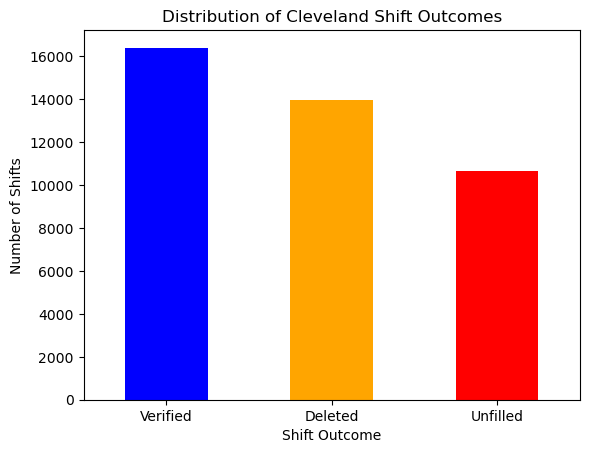

In [235]:
#6. Shift Outcomes Analysis

# so then since we re focusing on cleveland shifts, what were the outcomes of those shifts? 
# let's analyze the outcomes of the Cleveland shifts by cross-referencing the shifts that had bookings and cancellations with their verification status in the shifts table. 
# Every shift can have three possible outcomes:
# 1. Verified (worked successfully)
# 2. Canceled by facility (Deleted)
# 3. Unverified (nobody worked it, and it wasn't deleted)
# The facility needed coverage and got NOTHING.
# This is the worst outcome from the facility's perspective — they posted a shift, waited, and nobody came

# create a new column in the shifts table to categorize the outcome of each shift based on its verification status and deletion status. 

shifts["status"] = "Unfilled"  # default status
shifts.loc[shifts["Verified"] == True, "status"] = "Verified" #override to "Verified" if the shift was worked
shifts.loc[shifts["Deleted"].notna(), "status"] = "Deleted" #override to "Deleted" if the shift was deleted by the facility

#.loc[condition,column] = value 
print() 

# now count the outcome distribution for Cleveland shifts
clev_shift_outcomes = shifts["status"].value_counts()
print("\nCleveland Shift Outcomes:")
print(clev_shift_outcomes)  

print(shifts["status"].value_counts(normalize=True).mul(100).round(2))  # percentage distribution of outcomes

#visualize the distribution of shift outcomes using a bar chart
import matplotlib.pyplot as plt 
outcome_counts = shifts["status"].value_counts()
outcome_counts.plot(kind="bar", color=["blue", "orange", "red"])
plt.title("Distribution of Cleveland Shift Outcomes")
plt.xlabel("Shift Outcome")
plt.ylabel("Number of Shifts")
plt.xticks(rotation=0)
plt.show()



In [213]:
# RESULTS:
#   Verified:  16,400 (40.0%)  ← success
#   Deleted:   13,982 (34.1%)  ← facility gave up
#   Unfilled:  10,658 (26.0%)  ← total failure
#
# 40% success rate. 60% failure rate.
# That's the marketplace health. Everything in your
# proposal is about improving this number.

#### 7. What is the impact of cancellations on shift outcomes?


Cancellation Distribution by Lead Time Buckets:
lead_bucket
After start (NCNS)    11968
0-6h before           14118
6-12h before           5249
12-24h before          4952
1-2 days before        4777
2-7 days before       13297
>7 days before        23712
Name: count, dtype: int64
lead_bucket
After start (NCNS)    15.329243
0-6h before           18.083076
6-12h before           6.723195
12-24h before          6.342782
1-2 days before        6.118633
2-7 days before       17.031496
>7 days before        30.371575
Name: count, dtype: float64


Text(0.5, 0, 'Lead Time Buckets')

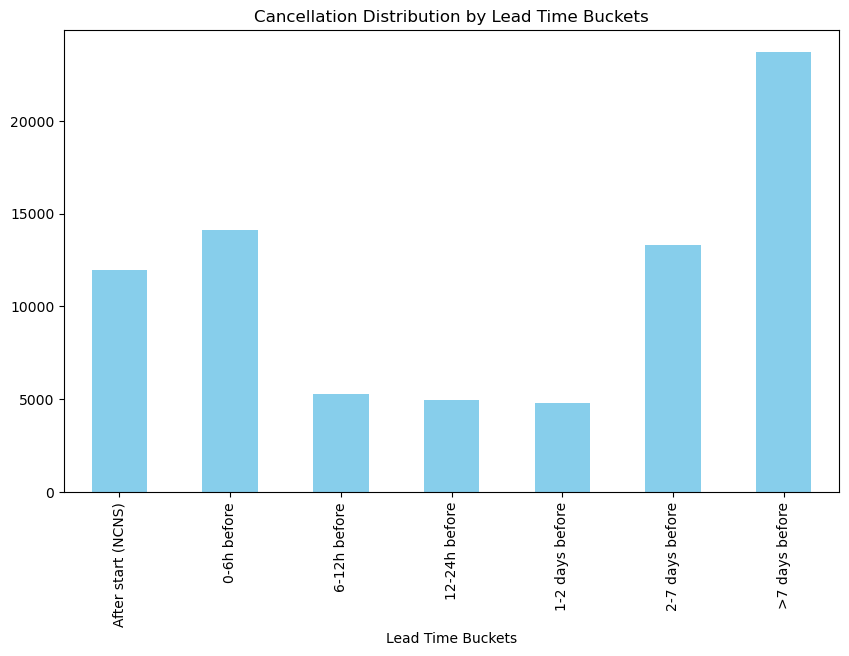

In [214]:
# 15.3% of cancellations are NCNS, which is the worst type of cancellation.
# 46.5% of cancellations happen with less than 24 hours notice, which is also very damaging for facilities.

# i used pd.cut() splits a continuous number into buckets (bins).
# Think of it like sorting mail into labeled boxes based on the value of "Lead Time".

cancel["lead_bucket"] = pd.cut(
    cancel["Lead Time"],                              # the column to bucket
    bins=[-np.inf, 0, 6, 12, 24, 48, 168, np.inf],   # the boundaries
    labels=[                                           # what to call each bucket
        "After start (NCNS)",    # Lead Time < 0: shift already started
        "0-6h before",           # 0 ≤ Lead Time < 6
        "6-12h before",          # 6 ≤ Lead Time < 12
        "12-24h before",         # 12 ≤ Lead Time < 24
        "1-2 days before",       # 24 ≤ Lead Time < 48
        "2-7 days before",       # 48 ≤ Lead Time < 168
        ">7 days before"         # Lead Time ≥ 168
    ]
)

# Now we can see the distribution of cancellations by these lead time buckets.
lead_time_distribution = cancel["lead_bucket"].value_counts().sort_index() #sort by the order of the buckets
print("\nCancellation Distribution by Lead Time Buckets:")
print(lead_time_distribution)
print(lead_time_distribution / len(cancel) * 100)  # percentage distribution of cancellations by lead time buckets

#visualization of cancellation distribution by lead time buckets
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
lead_time_distribution.sort_index().plot(kind='bar', color='skyblue')
plt.title('Cancellation Distribution by Lead Time Buckets')
plt.xlabel('Lead Time Buckets') 

In [215]:
# Results show that 46.48% of cancellations happen with less than 24 hours notice (combining the buckets "After start (NCNS)", "0-6h before", "6-12h before", and "12-24h before"). This indicates that a significant portion of cancellations occur very close to the shift start time
# which can be particularly disruptive for facilities as it leaves them with little time to find a replacement.
#  Additionally, 15.3% of cancellations are NCNS (After start), which is the worst type of cancellation as it provides no warning at all. This analysis highlights the critical need for solutions that can help reduce last-minute cancellations and improve communication between workers and facilities to mitigate the impact of these disruptive events.

#### 8. What is causing the problem???

Workers who cancel shifts at least once: 9,933

Distribution of cancellations per worker:
1      2070
2      1461
3      1014
4       777
5       600
       ... 
156       1
160       1
165       1
207       1
236       1
Name: count, Length: 103, dtype: int64

count    9933.00
mean        7.84
std        11.73
min         1.00
25%         2.00
50%         4.00
75%         9.00
max       236.00
dtype: float64


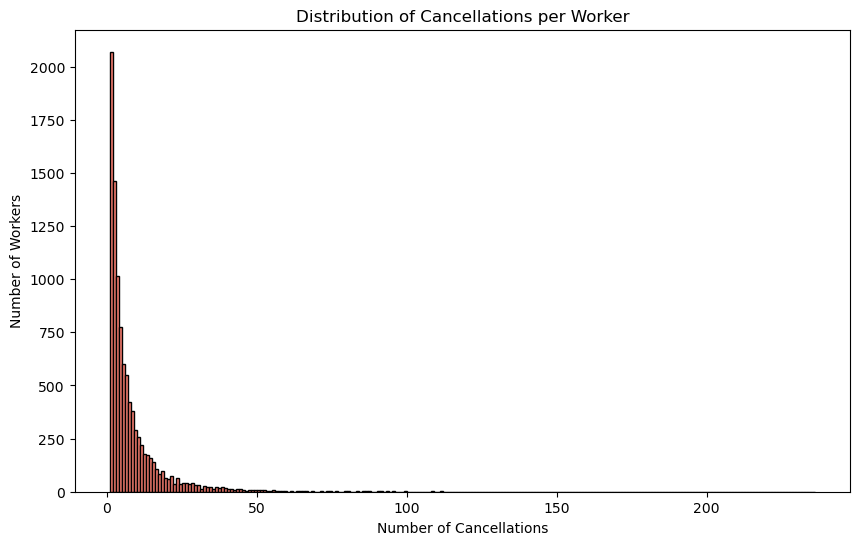



--- How concentrated is the problem? ---
Top 5% of cancellers (496 workers) account  for 22889 cancellations (29.4%)
Top 10% of cancellers (993 workers) account  for 33913 cancellations (43.5%)
Top 20% of cancellers (1986 workers) account  for 47870 cancellations (61.5%)
Top 50% of cancellers (4966 workers) account  for 68160 cancellations (87.5%)

Workers who had at least one NCNS cancellation: 4,774
  Workers with  1+ NCNS: 4,774 → 11,774 NCNS (100.0% of all NCNS)
  Workers with  2+ NCNS: 2,445 →  9,445 NCNS (80.2% of all NCNS)
  Workers with  3+ NCNS: 1,505 →  7,565 NCNS (64.3% of all NCNS)
  Workers with  4+ NCNS:   988 →  6,014 NCNS (51.1% of all NCNS)
  Workers with  5+ NCNS:   637 →  4,610 NCNS (39.2% of all NCNS)
  Workers with  6+ NCNS:   432 →  3,585 NCNS (30.4% of all NCNS)
  Workers with  7+ NCNS:   283 →  2,691 NCNS (22.9% of all NCNS)
  Workers with  8+ NCNS:   199 →  2,103 NCNS (17.9% of all NCNS)
  Workers with  9+ NCNS:   134 →  1,583 NCNS (13.4% of all NCNS)
  Worke

In [238]:
# what is the cause of the high cancellation rates?
# we can analyze the cancellation rates by worker ID to see if certain workers have higher cancellation rates than others. 
# This could help us identify if there are specific individuals who are more prone to canceling their shifts, which could be due to various factors such as sickness, family emergencies, or other personal reasons. 


# 8a: Calculate cancellation rates by worker ID
cancels_per_worker = cancel.groupby("Worker ID").size().sort_values(ascending=False)

print(f"Workers who cancel shifts at least once: {len(cancels_per_worker):,}") # total cancellations per worker
print(F"\nDistribution of cancellations per worker:")
print(cancels_per_worker.value_counts().sort_index()) # distribution of how many workers have 1 cancel, 2 cancels, etc.
print()
print(cancels_per_worker.describe().round(2)) # statistical summary of cancellations per worker

#visualize the distribution of cancellations per worker using a histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(cancels_per_worker, bins=range(1, cancels_per_worker.max() + 1), color='salmon', edgecolor='black')
plt.title('Distribution of Cancellations per Worker')
plt.xlabel('Number of Cancellations')
plt.ylabel('Number of Workers')
plt.show()

print() 

# 8b: do the top % of cancellers account for a % of cancels {concentration of cancellations among workers}
cancel_totals = cancels_per_worker.sum()

print("\n--- How concentrated is the problem? ---")
for top_percent in [5, 10, 20, 50]:
    top_n = int(len(cancels_per_worker) * top_percent / 100)
    top_cancellers = cancels_per_worker.head(top_n)
    top_cancels = top_cancellers.sum()
    print(f"Top {top_percent}% of cancellers ({top_n} workers) account  for {top_cancels} cancellations "
          f"({top_cancels / cancel_totals * 100:.1f}%)")


#8c ncns concentration among workers 
# first filter the cancel logs to only include NCNS cancellations, then calculate the number of NCNS cancellations per worker and analyze the concentration of NCNS cancellations among workers.
ncns_cancels = cancel[cancel["Action"] == "NO_CALL_NO_SHOW"]
ncns_per_worker = ncns_cancels.groupby("Worker ID").size().sort_values(ascending=False)

total_ncns = ncns_per_worker.sum()
print(f"\nWorkers who had at least one NCNS cancellation: {len(ncns_per_worker):,}")

for threshold in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    above = ncns_per_worker[ncns_per_worker >= threshold]
    print(f"  Workers with {threshold:>2d}+ NCNS: {len(above):>5,} "
          f"→ {above.sum():>6,} NCNS "
          f"({above.sum()/total_ncns*100:.1f}% of all NCNS)")

- results from the cancellations via worker id analysis 
- about 9933 healthcare professionals cancelled at least once 
- one HCP cancelled 236 times 
- the average is 7.8 cancels per worker and median is 4 --> the distribution is skewed 

- top 5% of cancels are 29.4% of the total cancellations 
- top 10% are 43.5% of the cancellers 
- top 20% are 61.5% of cancellers 
- top 50% are 87.5% of cancellers 

- apparently called a parento pattern (80/20) rule where the minority in the groupdrives most of the cancellatons 
- My first true finding?



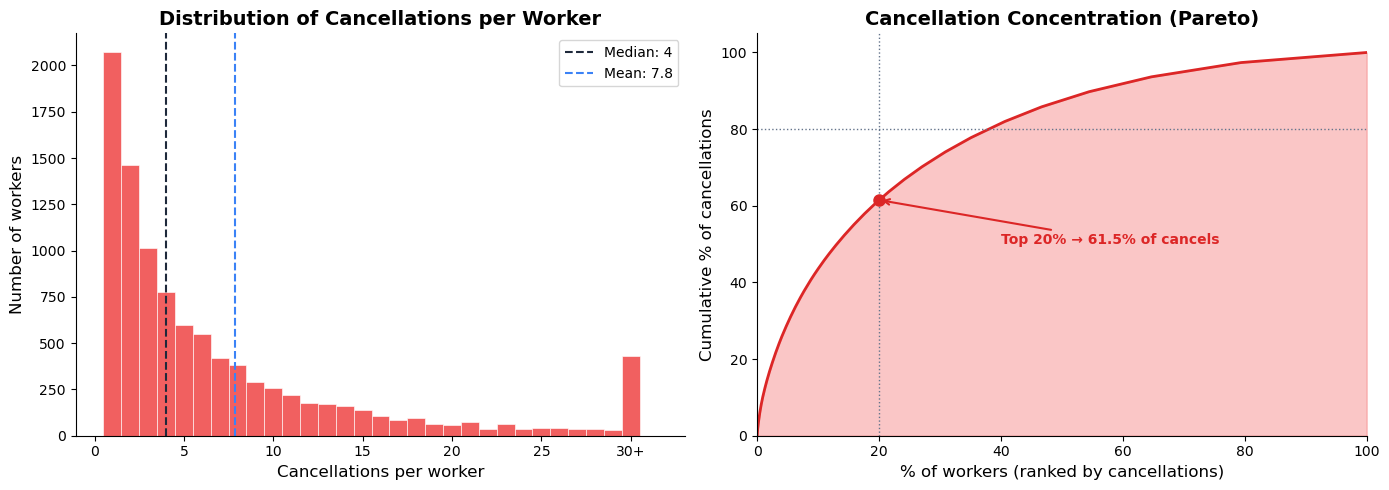

Total workers who cancelled: 9,933
Mean: 7.8 | Median: 4 | Max: 236
Workers with 1 cancel only: 2,070 (20.8%)
Workers with 10+ cancels: 2,372 (23.9%)


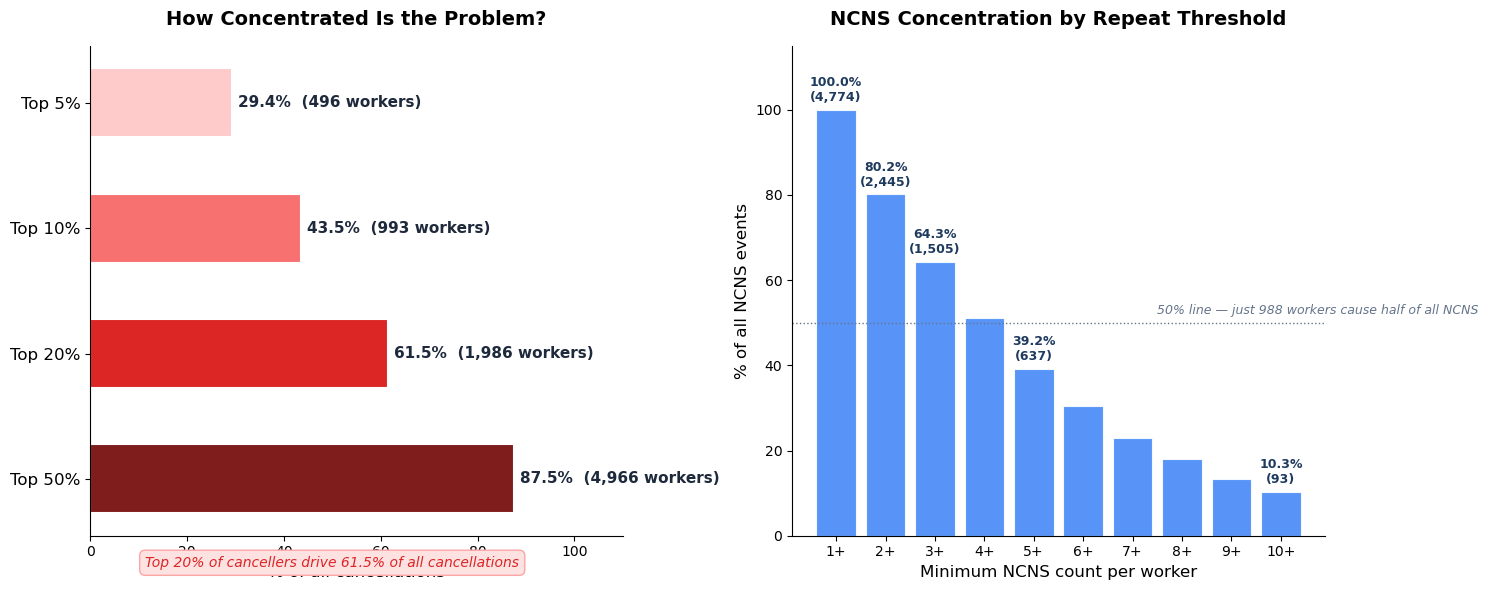

In [248]:
# visualisation for pareto principle/concentration 
import matplotlib.pyplot as plt
import numpy as np

# cancellations per worker (you already have this)
cancels_per_worker = cancel.groupby("Worker ID").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Histogram (capped at 30 for readability) ---
ax1 = axes[0]
capped = cancels_per_worker.clip(upper=30)
bins = np.arange(0.5, 32.5, 1)
ax1.hist(capped, bins=bins, color='#ef4444', edgecolor='white', linewidth=0.5, alpha=0.85)
ax1.axvline(cancels_per_worker.median(), color='#1e293b', linestyle='--', linewidth=1.5,
            label=f'Median: {cancels_per_worker.median():.0f}')
ax1.axvline(cancels_per_worker.mean(), color='#3b82f6', linestyle='--', linewidth=1.5,
            label=f'Mean: {cancels_per_worker.mean():.1f}')

ax1.set_xlabel('Cancellations per worker', fontsize=12)
ax1.set_ylabel('Number of workers', fontsize=12)
ax1.set_title('Distribution of Cancellations per Worker', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks(range(0, 32, 5))
labels = [str(x) for x in range(0, 30, 5)] + ['30+']
ax1.set_xticklabels(labels)

# --- Right: Concentration / Pareto ---
ax2 = axes[1]
sorted_cancels = cancels_per_worker.values  # already descending
cumulative_pct = np.cumsum(sorted_cancels) / sorted_cancels.sum() * 100
worker_pct = np.arange(1, len(sorted_cancels) + 1) / len(sorted_cancels) * 100

ax2.fill_between(worker_pct, cumulative_pct, alpha=0.3, color='#ef4444')
ax2.plot(worker_pct, cumulative_pct, color='#dc2626', linewidth=2)

# reference lines for 20/80
ax2.axhline(80, color='#64748b', linestyle=':', linewidth=1)
ax2.axvline(20, color='#64748b', linestyle=':', linewidth=1)
ax2.plot(20, 61.5, 'o', color='#dc2626', markersize=8, zorder=5)
ax2.annotate('Top 20% → 61.5% of cancels',
             xy=(20, 61.5), xytext=(40, 50),
             fontsize=10, fontweight='bold', color='#dc2626',
             arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.5))

ax2.set_xlabel('% of workers (ranked by cancellations)', fontsize=12)
ax2.set_ylabel('Cumulative % of cancellations', fontsize=12)
ax2.set_title('Cancellation Concentration (Pareto)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 105)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# --- Summary stats ---
print(f"Total workers who cancelled: {len(cancels_per_worker):,}")
print(f"Mean: {cancels_per_worker.mean():.1f} | Median: {cancels_per_worker.median():.0f} | Max: {cancels_per_worker.max()}")
print(f"Workers with 1 cancel only: {(cancels_per_worker == 1).sum():,} ({(cancels_per_worker == 1).mean()*100:.1f}%)")
print(f"Workers with 10+ cancels: {(cancels_per_worker >= 10).sum():,} ({(cancels_per_worker >= 10).mean()*100:.1f}%)")


import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Cancellation Concentration ---
tiers = ['Top 5%', 'Top 10%', 'Top 20%', 'Top 50%']
workers = [496, 993, 1986, 4966]
pcts = [29.4, 43.5, 61.5, 87.5]
colors_left = ['#fecaca', '#f87171', '#dc2626', '#7f1d1d']

bars = ax1.barh(tiers[::-1], pcts[::-1], color=colors_left[::-1], height=0.55, edgecolor='white', linewidth=1.5)

for bar, pct, w in zip(bars, pcts[::-1], workers[::-1]):
    ax1.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height()/2,
             f'{pct}%  ({w:,} workers)',
             va='center', fontsize=11, fontweight='bold', color='#1e293b')

ax1.set_xlim(0, 110)
ax1.set_xlabel('% of all cancellations', fontsize=12)
ax1.set_title('How Concentrated Is the Problem?', fontsize=14, fontweight='bold', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='y', labelsize=12)

# annotation
ax1.text(50, -0.7, 'Top 20% of cancellers drive 61.5% of all cancellations',
         ha='center', fontsize=10, fontstyle='italic', color='#dc2626',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fee2e2', edgecolor='#fca5a5'))


# --- Right: NCNS Concentration by Threshold ---
thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
ncns_pcts = [100.0, 80.2, 64.3, 51.1, 39.2, 30.4, 22.9, 17.9, 13.4, 10.3]
worker_counts = [4774, 2445, 1505, 988, 637, 432, 283, 199, 134, 93]

ax2.bar(thresholds, ncns_pcts, color='#3b82f6', edgecolor='white', linewidth=0.8, alpha=0.85)

# label key bars only to avoid clutter
for i in [0, 1, 2, 4, 9]:  # 1+, 2+, 3+, 5+, 10+
    ax2.text(thresholds[i], ncns_pcts[i] + 2,
             f'{ncns_pcts[i]}%\n({worker_counts[i]:,})',
             ha='center', fontsize=9, fontweight='bold', color='#1e3a5f')

ax2.set_xlabel('Minimum NCNS count per worker', fontsize=12)
ax2.set_ylabel('% of all NCNS events', fontsize=12)
ax2.set_title('NCNS Concentration by Repeat Threshold', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(thresholds)
ax2.set_xticklabels([f'{t}+' for t in thresholds])
ax2.set_ylim(0, 115)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# key insight line
ax2.axhline(50, color='#64748b', linestyle=':', linewidth=1)
ax2.text(7.5, 52, '50% line — just 988 workers cause half of all NCNS',
         fontsize=9, color='#64748b', fontstyle='italic')

plt.tight_layout()
plt.show()

In [253]:
# 9: Which Shifts get impacted the most by cancellations?
# we can analyze the cancellation rates by shift type and agent requirement to see if certain types of shifts are more prone to cancellations.

# 9a: Calculate cancellation rates by shift type: To see what shifts are most prone 
# filter cancel log to only cleveland shifts 

clev_canceled = cancel[cancel["Shift ID"].isin(clev_shift_ids).copy()]

#summarise cancels per shift 
shift_cancel_info = clev_canceled.groupby("Shift ID").agg(
    cancellations=("Action ID", "count"),  # total cancellations for each shift    
    had_ncns = ("is_ncns", "any"),
    had_late_cancel = ("is_late", "any")

)   
print(shift_cancel_info.head()) # show first few rows of the cancellation summary per shift

#merge with shifts data to get shift type and agent req info
shifts_analysis= shifts.merge(shift_cancel_info, on="Shift ID", how="left") # left join to keep all shifts, even those with no cancels

# Fill Nan with 0 for shifts that had no cancels
shifts_analysis["cancellations"] = shifts_analysis["cancellations"].fillna(0).astype(int) # convert to integer
shifts_analysis["had_ncns"] = shifts_analysis["had_ncns"].fillna(False)
shifts_analysis["had_late_cancel"] = shifts_analysis["had_late_cancel"].fillna(False)
shifts_analysis["was_cancelled"] = shifts_analysis["cancellations"] > 0

# Now we can analyze cancellation rates by shift type and agent requirement

# Cancellation Rate = % of shifts that had at least one cancellation 
for time in ["am", "pm", "noc", "custom"]: #shift type 
    subset = shifts_analysis[shifts_analysis["Shift Type"] == time]
    cancel_rate = subset["was_cancelled"].mean() * 100
    ncns_rate = subset["had_ncns"].mean() * 100
    fill_rate = subset["Verified"].mean() * 100
    print(f"\nShift Type: {time}")
    print(f"  Cancellation Rate: {cancel_rate:.2f}%")
    print(f"  NCNS Rate: {ncns_rate:.2f}%")
    print(f"  Fill Rate: {fill_rate:.2f}%")
# cancellation rates are fairly similar across shift types, with custom shifts having a slightly higher cancellation rate. 
# 
# Cancellation rates by agent requirement (worker type needed) 
for agent in ["CNA", "LVN", "RN", "NURSE", "CAREGIVER", "Medical Tech", "PT", "Medical Aide"]:
    subset = shifts_analysis[shifts_analysis["Agent Req"] == agent]
    cancel_rate = subset["was_cancelled"].mean() * 100
    ncns_rate = subset["had_ncns"].mean() * 100
    fill_rate = subset["Verified"].mean() * 100
    charge = subset["Charge"].mean()

    print(f"\nAgent Req: {agent}")
    print(f"  Cancellation Rate: {cancel_rate:.2f}%")
    print(f"  NCNS Rate: {ncns_rate:.2f}%")
    print(f"  Fill Rate: {fill_rate:.2f}%")
    print(f"  Average Charge: ${charge:.2f}")
# CNA has the highest cancellation rate 




                          cancellations  had_ncns  had_late_cancel
Shift ID                                                          
611e19db7a78980166b3a477              1      True             True
611e19de19b9a80166c305dc              1     False            False
611e19e102f50b0166eb1d74              3      True             True
611e19e5e13dc70166aac84e              1     False             True
61269a773ee0c501660e75a1              1     False            False

Shift Type: am
  Cancellation Rate: 15.53%
  NCNS Rate: 3.59%
  Fill Rate: 38.81%

Shift Type: pm
  Cancellation Rate: 15.82%
  NCNS Rate: 2.82%
  Fill Rate: 38.84%

Shift Type: noc
  Cancellation Rate: 17.34%
  NCNS Rate: 2.75%
  Fill Rate: 44.67%

Shift Type: custom
  Cancellation Rate: 9.36%
  NCNS Rate: 2.55%
  Fill Rate: 24.38%

Agent Req: CNA
  Cancellation Rate: 20.24%
  NCNS Rate: 4.22%
  Fill Rate: 50.69%
  Average Charge: $30.71

Agent Req: LVN
  Cancellation Rate: 9.57%
  NCNS Rate: 1.30%
  Fill Rate: 27.58%
  Ave

C:\Users\TEST\AppData\Local\Temp\ipykernel_16580\2873730127.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifts_analysis["had_ncns"] = shifts_analysis["had_ncns"].fillna(False)
C:\Users\TEST\AppData\Local\Temp\ipykernel_16580\2873730127.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifts_analysis["had_late_cancel"] = shifts_analysis["had_late_cancel"].fillna(False)


- from cancellation analyisis by shift type and worker type 
- from shift type: nocturnal had most cancellations at 20.6%, pm - 18.8%, am 18.6% and custom shifts at 10.6%. pretty consistent am & pm are the same. nothing particularly jumps out but it is worth to note 
- from agent req: 
- the differences were wider so this matters more 

In [218]:
# 10: What happens when a shift gets canceled? Do facilities delete it, or do they just leave it unfilled?
# we can analyze the outcomes of canceled shifts by looking at the "Deleted" and "Verified" columns.
# This will help us understand how facilities respond to cancellations

print("\n--- Outcomes of Canceled Shifts ---")
ncns_Shifts = shifts_analysis[shifts_analysis["had_ncns"]==True]
non_ncns = shifts_analysis[shifts_analysis["had_ncns"]==False]

print(f"Shifts with NCNS cancellations: {len(ncns_Shifts):,}")
print(f" Re-verified (someone else worked it): {ncns_Shifts['Verified'].mean() * 100:.1f}%")
print(f" Deleted by facility: {ncns_Shifts['Deleted'].notna().mean() * 100:.1f}%")
print(f" Left unfilled: {(ncns_Shifts['Deleted'].isna() & (ncns_Shifts['Verified'] == False)).mean() * 100:.1f}%")

print(f"\nShifts with non-NCNS cancellations: {len(non_ncns):,}")
print(f" Re-verified (someone else worked it): {non_ncns['Verified'].mean() * 100:.1f}%")
print(f" Deleted by facility: {non_ncns['Deleted'].notna().mean() * 100:.1f}%")
print(f" Left unfilled: {(non_ncns['Deleted'].isna() & (non_ncns['Verified'] == False)).mean() * 100:.1f}%")





--- Outcomes of Canceled Shifts ---
Shifts with NCNS cancellations: 1,253
 Re-verified (someone else worked it): 15.7%
 Deleted by facility: 2.6%
 Left unfilled: 81.6%

Shifts with non-NCNS cancellations: 39,787
 Re-verified (someone else worked it): 40.7%
 Deleted by facility: 35.1%
 Left unfilled: 24.2%


--- Outcomes of Canceled Shifts ---
- Shifts with NCNS cancellations: 1,253
- Re-verified (someone else worked it): 15.7%
- Deleted by facility: 2.6%
- Left unfilled: 81.6%

Shifts with non-NCNS cancellations: 39,787
- Re-verified (someone else worked it): 40.7%
- Deleted by facility: 35.1%
- Left unfilled: 24.2%

#### killer stat:: when an NCNS happens there's an 82% chance the facility gets zero coverage 

In [219]:
# When an NCNS happens, there's an 82% chance the facility
# gets ZERO coverage. The marketplace almost never recovers
# from a no-show. This number belongs in your proposal.
 

In [220]:
# 11. Recovery analysis continued; so when a shift gets canceled does another worker book it and work it? 

canceled_shift_set = set(cancel["Shift ID"]) 
booked_shift_set = set(booking["Shift ID"])

recovered_shifts = booked_shift_set.intersection(canceled_shift_set) #shifts of both booked and canceled, also booked by another 
print(f"Number of canceled shifts that got re-booked: {len(recovered_shifts)}")

not_rebooked = canceled_shift_set - booked_shift_set
print(f"Number of canceled shifts that did NOT get re-booked: {len(not_rebooked)}")

print(f"\nAcross all markets:")
print(f"  Canceled shifts:  {len(canceled_shift_set):,}")
print(f"  Got rebooked:     {len(recovered_shifts):,} ({len(recovered_shifts)/len(canceled_shift_set)*100:.1f}%)")
print(f"  NOT rebooked:     {len(not_rebooked):,} ({len(not_rebooked)/len(canceled_shift_set)*100:.1f}%)")

# 11B: Rebooking Analysis specifically for NCNS shifts
ncns_shift_set = set(cancel[cancel["is_ncns"]]["Shift ID"])
ncns_rebooked = ncns_shift_set.intersection(booked_shift_set)
ncns_not_rebooked = ncns_shift_set - booked_shift_set

print() 

print(f"\nNCNS shifts specifically:")
print(f" Total NCNS shifts: {len(ncns_shift_set):,}")
print(f" Got rebooked:     {len(ncns_rebooked):,} ({len(ncns_rebooked)/len(ncns_shift_set)*100:.1f}%)")
print(f" NOT rebooked:     {len(ncns_not_rebooked):,} ({len(ncns_not_rebooked)/len(ncns_shift_set)*100:.1f}%)")


Number of canceled shifts that got re-booked: 23090
Number of canceled shifts that did NOT get re-booked: 42472

Across all markets:
  Canceled shifts:  65,562
  Got rebooked:     23,090 (35.2%)
  NOT rebooked:     42,472 (64.8%)


NCNS shifts specifically:
 Total NCNS shifts: 11,877
 Got rebooked:     4,291 (36.1%)
 NOT rebooked:     7,586 (63.9%)


- only 35% of cancelled shifts get rebooked; across all markets 
- only 36% of NCNS shifts get rebooked, across all markets 
- this is insane considering that, cleveland shifts has a high 82% chance that those shifts go unfilled 
- so generally the situation is dire across the marketplace 



In [221]:
# Section 12: Verified Shifts with Cancelled Records 
# We can analyze if there are any shifts that were marked as verified (worked) in the shifts table but have corresponding cancellation records in the cancel logs.
# Why: I want to know if cleveland are successfully saving any shifts that had cancellations 

verified_ids = set(shifts[shifts["Verified"] == True]["Shift ID"])
clev_canceled_ids = set(clev_canceled["Shift ID"])

# shifts that were canceled but verified as worked
clev_saved = verified_ids.intersection(clev_canceled_ids)


print(f"\n Cleveland Shifts that were marked as verified but had cancellation records: {len(clev_saved):,}")
print(f"\nCleveland shifts that had a cancellation and still got fulfilled:")
print(f"  Total Saved: {len(clev_saved):,} out of {len(clev_canceled_ids):,} canceled shifts")

#hence recovery rate is

# Recovery Rate = (Shifts that were canceled but still got fulfilled) / (Total Canceled Shifts) * 100

recovery_rate = len(clev_saved) / len(clev_canceled_ids) * 100
print(f"  Recovery Rate: {recovery_rate:.1f}%") 

# recovery rate is 38% for cleveland shifts that had cancellations, higher than the rebooking rate of 35%  across the market
# so can cleveland improve recovery or reduce cancellations to get more shifts fulfilled?






 Cleveland Shifts that were marked as verified but had cancellation records: 2,501

Cleveland shifts that had a cancellation and still got fulfilled:
  Total Saved: 2,501 out of 6,535 canceled shifts
  Recovery Rate: 38.3%


In [222]:
# 13: Financial Implications 
# take rate = 22%
TAKE_RATE

avg_charge = shifts["Charge"].mean() #average $ per shift 
avg_revenue = avg_charge * TAKE_RATE # Clipboard's cut 

# Revenue from shifts worked 
verified_revenue = shifts[shifts["Verified"]]["Charge"].sum() * TAKE_RATE

# Revenue lost from unfilled shifts (opportunity cost) 
unfilled_count = (shifts_analysis["status"] == "Unfilled").sum()
unfilled_revenue = unfilled_count * avg_charge

print(f"\nFinancial Implications:")
print(f"  Verified Revenue: ${verified_revenue:,.2f}")
print(f"  Unfilled Revenue Lost: ${unfilled_revenue:,.2f}")

# Revenue specifically lost from NCNS shifts
ncns_count_cleveland = shifts_analysis[shifts_analysis["had_ncns"] == True].shape[0]
ncns_revenue_lost = ncns_count_cleveland * avg_charge

print(f"\n -- Financial Implications of Cleveland ")
print(f"Avg charge per shift:          ${avg_charge:.2f}")
print(f"Clipboard revenue per shift:   ${avg_revenue:.2f}")
print(f"")
print(f"Revenue earned (verified):     ${verified_revenue:,.0f}")
print(f"Revenue lost (unfilled):       ${unfilled_revenue:,.0f}")
print(f"Revenue lost (NCNS shifts):    ${ncns_revenue_lost:,.0f}")
print(f"")
print(f"Monthly revenue:               ${verified_revenue/4:,.0f}")
print(f"Monthly NCNS loss:             ${ncns_revenue_lost/4:,.0f}")
 


Financial Implications:
  Verified Revenue: $144,436.93
  Unfilled Revenue Lost: $387,452.71

 -- Financial Implications of Cleveland 
Avg charge per shift:          $36.35
Clipboard revenue per shift:   $8.00

Revenue earned (verified):     $144,437
Revenue lost (unfilled):       $387,453
Revenue lost (NCNS shifts):    $45,551

Monthly revenue:               $36,109
Monthly NCNS loss:             $11,388


In [223]:
# These are DIRECT revenue losses only.
# The INDIRECT cost (facility loses trust → posts fewer shifts
# → eventually leaves the platform) is much larger but harder
# to calculate. Your proposal should mention this qualitatively.

In [224]:
# Run this before pd.cut to verify the raw data is still there
print(booking[booking["Lead Time"] <= 12]["Lead Time"].describe())
print(f"\nBookings with Lead Time <= 12h: {(booking['Lead Time'] <= 12).sum():,}")

count    9898.000000
mean      -24.878926
std        97.527520
min     -3271.273333
25%        -7.841389
50%         2.259722
75%         6.496666
max        11.999722
Name: Lead Time, dtype: float64

Bookings with Lead Time <= 12h: 9,898



--- NCNS rate by day of week ---
 Monday        11,186 total, 1,854 NCNS (16.6%)
 Tuesday        8,340 total, 1,368 NCNS (16.4%)
 Wednesday      8,303 total, 1,389 NCNS (16.7%)
 Thursday       8,913 total, 1,340 NCNS (15.0%)
 Friday        11,070 total, 1,600 NCNS (14.5%)
 Saturday      14,749 total, 2,117 NCNS (14.4%)
 Sunday        15,512 total, 2,297 NCNS (14.8%)

 --- Cancel rate by booking lead time --- 
 Booked 0-12h       :   9,898 bookings,  3,002 canceled (30.3%)
 Booked 12-24h      :   6,553 bookings,  1,900 canceled (29.0%)
 Booked 1-2 days    :  10,198 bookings,  2,829 canceled (27.7%)
 Booked 2-7 days    :  43,404 bookings, 11,439 canceled (26.4%)
 Booked 1-2 weeks   :  31,883 bookings, 10,202 canceled (32.0%)
 Booked >2 weeks    :  25,069 bookings,  8,579 canceled (34.2%)


C:\Users\TEST\AppData\Local\Temp\ipykernel_16580\3348090439.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_time_cancellation = booking.groupby("lead_bucket")["eventually_canceled"].mean() * 100


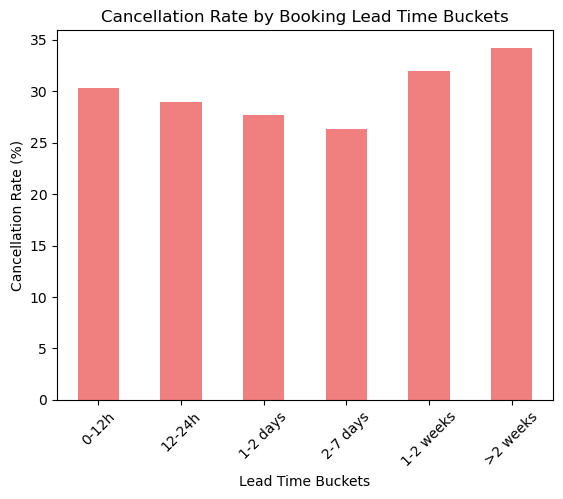

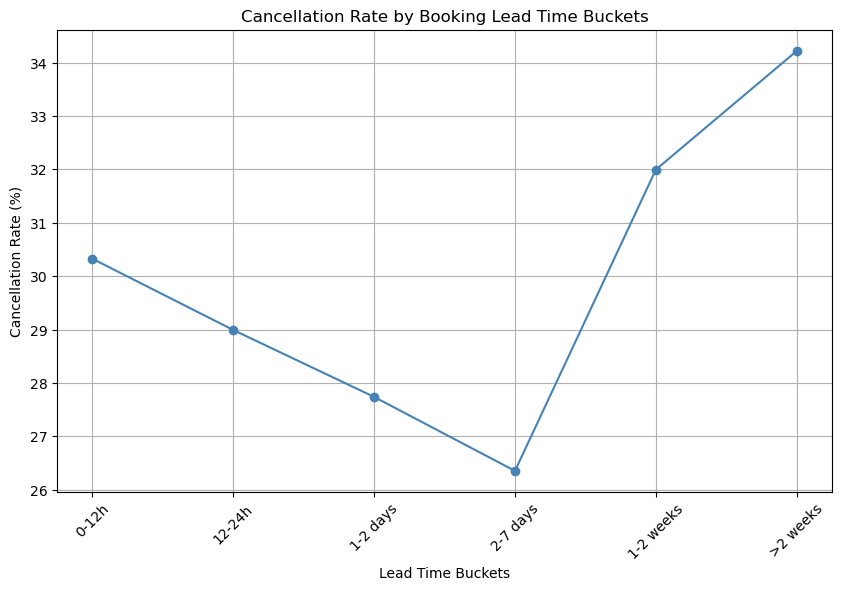

In [225]:
# 14: TIME PATTERNS IN CANCELLATIONS
# 14a: -- NCNS by day of week --
cancel["Start"] = pd.to_datetime(cancel["Start"], format="mixed")
cancel["day_of_week"] = cancel["Start"].dt.day_name() # extract day of week from shift to start time 

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print("\n--- NCNS rate by day of week ---")
for day in day_order:
    day_data = cancel[cancel["day_of_week"] == day]
    total = len(day_data)
    ncns = day_data["is_ncns"].sum()
    rate = ncns / total * 100 if total > 0 else 0
    print(f" {day:<12} {total:>7,} total, {ncns:>5,} NCNS ({rate:.1f}%)")
    
# 14b: -- booking lead time predict cancellation?  --
# we can analyze if the lead time (time between booking and shift start) has any correlation with cancellation rates.

# for each booking, check if that shift ended up canceled 
booking["eventually_canceled"] = booking["Shift ID"].isin(canceled_shift_set)

# analyze cancellation rates by lead time buckets
booking["lead_bucket"] = pd.cut(
    booking["Lead Time"],
    bins=[-np.inf, 12, 24, 48, 168, 336, float("inf")],
    labels=[
        "0-12h",
        "12-24h",
        "1-2 days",
        "2-7 days",
        "1-2 weeks",
        ">2 weeks"
    ]
)

print(f"\n --- Cancel rate by booking lead time --- ")

for bucket in ["0-12h", "12-24h", "1-2 days", "2-7 days", "1-2 weeks", ">2 weeks"]:
    subset = booking[booking["lead_bucket"] == bucket]
    total = len(subset)
    canceled = subset["eventually_canceled"].sum()
    rate = canceled / total * 100 if total > 0 else 0
    print(f" Booked {bucket:<12s}: {total:>7,} bookings, {canceled:>6,} canceled ({rate:.1f}%)")

#visualise the cancellation rate by booking lead time buckets
import matplotlib.pyplot as plt
lead_time_cancellation = booking.groupby("lead_bucket")["eventually_canceled"].mean() * 100
lead_time_cancellation.plot(kind="bar", color="lightcoral")
plt.title("Cancellation Rate by Booking Lead Time Buckets")
plt.xlabel("Lead Time Buckets")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

#another visualisation of cancellation rate by booking lead time buckets using a line chart
plt.figure(figsize=(10, 6))
lead_time_cancellation.plot(kind="line", marker="o", color="steelblue")
plt.title("Cancellation Rate by Booking Lead Time Buckets")
plt.xlabel("Lead Time Buckets")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.grid()
plt.show()



In [226]:
# Summarize each facility's stats 

facility_stats = shifts_analysis.groupby("Facility ID").agg(
    total_shifts=("Shift ID", "count"),
    filled_shifts=("Verified", "sum"),
    ncns_events=("had_ncns", "sum"), 
    late_cancels=("had_late_cancel", "sum"),
    avg_charge=("Charge", "mean"),
).sort_values(by="total_shifts", ascending=False)
print(facility_stats.head())


facility_stats["fill_rate"] = (facility_stats["filled_shifts"] / facility_stats["total_shifts"] * 100).round(2)
facility_stats["ncns_rate"] = (facility_stats["ncns_events"] / facility_stats["total_shifts"] * 100).round(2)

print(f"\n --- Facility Summary (top 10 by volume) ---")
print(facility_stats[["total_shifts", "fill_rate", "ncns_rate"]].head(10))


# NCNS concentration across facilities 

print(f"\n--- NCNS Concentration Across Facilities ---")

fac_sorted = facility_stats.sort_values("ncns_events", ascending=False)
total_fac_ncns = facility_stats["ncns_events"].sum()

for pct in [10, 20, 50]:
    n = max(1, int(len(fac_sorted) * pct / 100))
    top_facs = fac_sorted.head(n)
    their_ncns = top_facs["ncns_events"].sum()
    print(f"  Top {pct}% facilities ({n}): "
          f"{their_ncns:.0f}/{total_fac_ncns:.0f} NCNS "
          f"({their_ncns/total_fac_ncns*100:.1f}%)")

                          total_shifts  filled_shifts  ncns_events  \
Facility ID                                                          
5f9ad22ae3a95f0016090f97          3138            731           58   
5f9c169622c5c50016d5ba32          2974           1319           67   
5f9c119522c5c50016d5b89e          2916            911          105   
5f91b184cb91b40016e1e183          2362           1305           66   
5fa0a33daaa281001684ade2          1833            447           36   

                          late_cancels  avg_charge  
Facility ID                                         
5f9ad22ae3a95f0016090f97           186   42.202040  
5f9c169622c5c50016d5ba32           189   40.101210  
5f9c119522c5c50016d5b89e           283   25.777435  
5f91b184cb91b40016e1e183           185   41.217930  
5fa0a33daaa281001684ade2           142   43.971631  

 --- Facility Summary (top 10 by volume) ---
                          total_shifts  fill_rate  ncns_rate
Facility ID                    

In [227]:
# Results are fairly flat across all days 
# day of the week targetting would not achieve much reduction in NCNS rates, as the rates are similar across all days.


#  from chapter 15

#--- NCNS Concentration Across Facilities ---
 # Top 10% facilities (6): 454/1253 NCNS (36.2%)
  # Top 20% facilities (13): 775/1253 NCNS (61.9%)
  # Top 50% facilities (33): 1181/1253 NCNS (94.3%)

In [228]:

# how big is each table ( counting rows, unique shift ids, worker ids and facility ids)
for df, name in [(booking, "Booking Logs"), (cancel, "Cancel Logs"), (shifts, "Cleveland Shifts")]:
    print(f"\n--- {name} Summary ---")
    print(f"Total Records: {df.shape[0]}")
    print(f"Unique Shift IDs: {df['Shift ID'].nunique()}")
    print(f"Unique Worker IDs: {df['Worker ID'].nunique()}")
    print(f"Unique Facility IDs: {df['Facility ID'].nunique()}")



--- Booking Logs Summary ---
Total Records: 127005
Unique Shift IDs: 108662
Unique Worker IDs: 6841
Unique Facility IDs: 1118

--- Cancel Logs Summary ---
Total Records: 78073
Unique Shift IDs: 65562
Unique Worker IDs: 9933
Unique Facility IDs: 1416

--- Cleveland Shifts Summary ---
Total Records: 41040
Unique Shift IDs: 41040
Unique Worker IDs: 997
Unique Facility IDs: 67


### Further Visualisations to support proposal 
#### Shift Outcomes and NCNS Damage 



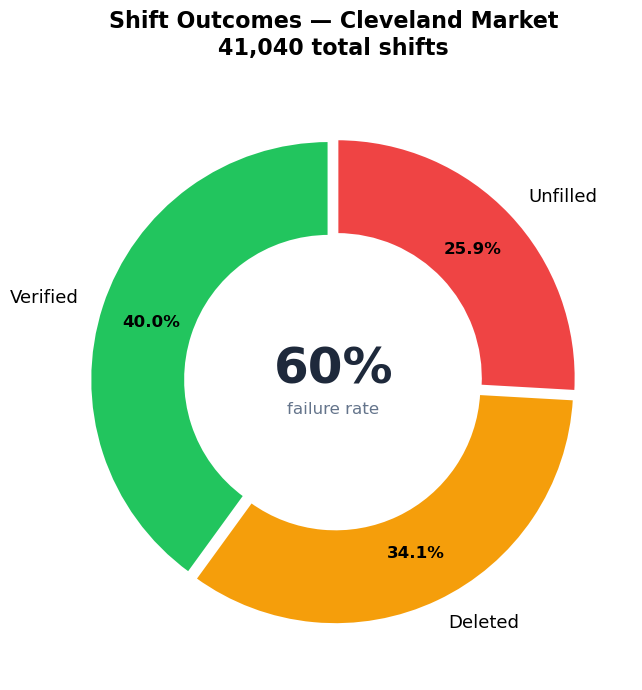

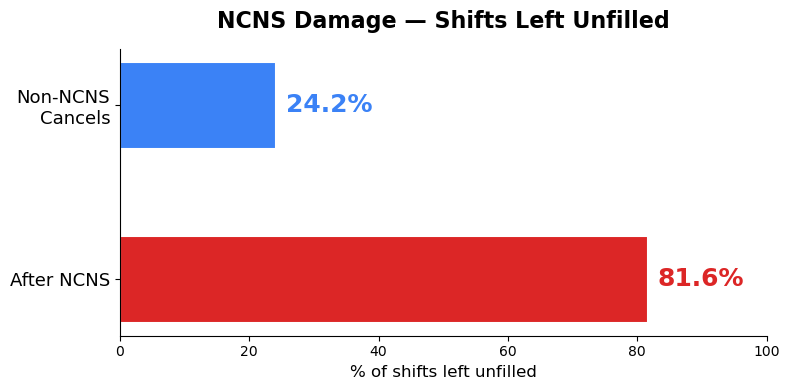

In [246]:
import matplotlib.pyplot as plt
import matplotlib

# --- Chart 1: Shift Outcomes Donut ---
labels = ['Verified', 'Deleted', 'Unfilled']
sizes = [40.0, 34.1, 25.9]
colors = ['#22c55e', '#f59e0b', '#ef4444']
explode = (0.02, 0.02, 0.02)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
for t in texts:
    t.set_fontsize(13)

centre = plt.Circle((0, 0), 0.45, fc='white')
ax.add_artist(centre)
ax.text(0, 0.05, '60%', ha='center', va='center', fontsize=36, fontweight='bold', color='#1e293b')
ax.text(0, -0.12, 'failure rate', ha='center', va='center', fontsize=12, color='#64748b')

ax.set_title('Shift Outcomes — Cleveland Market\n41,040 total shifts',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# --- Chart 2: NCNS Damage Comparison ---
categories = ['After NCNS', 'Non-NCNS\nCancels']
values = [81.6, 24.2]
colors = ['#dc2626', '#3b82f6']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(categories, values, color=colors, height=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', ha='left', fontsize=18, fontweight='bold',
            color=bar.get_facecolor())

ax.set_xlim(0, 100)
ax.set_xlabel('% of shifts left unfilled', fontsize=12)
ax.set_title('NCNS Damage — Shifts Left Unfilled',
             fontsize=16, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=13)


plt.tight_layout()
plt.show()